In [3]:
import imageio.v3 as imageio
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import hamming
from model_ranking import (
    get_unique_colourmap,
    get_mask,
    get_segmentation_mask,
    HammingDistanceEval, 
    AdaptedRandErrorEval,
)

INFO: P [MainThread] 2025-10-06 19:18:19,632 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


/g/kreshuk/talks/miniforge3/envs/model-rank-local2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/g/kreshuk/talks/pytorch-3dunet/pytorch3dunet/unet3d/predictor.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
pred_01_path = "/g/kreshuk/talks/toothfairy/preds/normal/Dataset666_ToothFairy2/inferTs_nnUNetTrainerVMamba__nnUNetPlans__2d__0/K001.mha"
pred_01_gauss05_path = "/g/kreshuk/talks/toothfairy/preds/noisy/sigma_0.5x/Dataset666_ToothFairy2/inferTs_nnUNetTrainerVMamba__nnUNetPlans__2d__0/K001.mha"
pred_01_gaussx1_path = "/g/kreshuk/talks/toothfairy/preds/noisy/sigma_1.0x/Dataset666_ToothFairy2/inferTs_nnUNetTrainerVMamba__nnUNetPlans__2d__0/K001.mha"
gauss_01_gaussx15_path = "/g/kreshuk/talks/toothfairy/preds/noisy/sigma_1.5x/Dataset666_ToothFairy2/inferTs_nnUNetTrainerVMamba__nnUNetPlans__2d__0/K001.mha"

In [5]:
im_NA = imageio.imread(pred_01_path)
im_gauss05 = imageio.imread(pred_01_gauss05_path)
im_gauss1 = imageio.imread(pred_01_gaussx1_path)
im_gauss15 = imageio.imread(gauss_01_gaussx15_path)

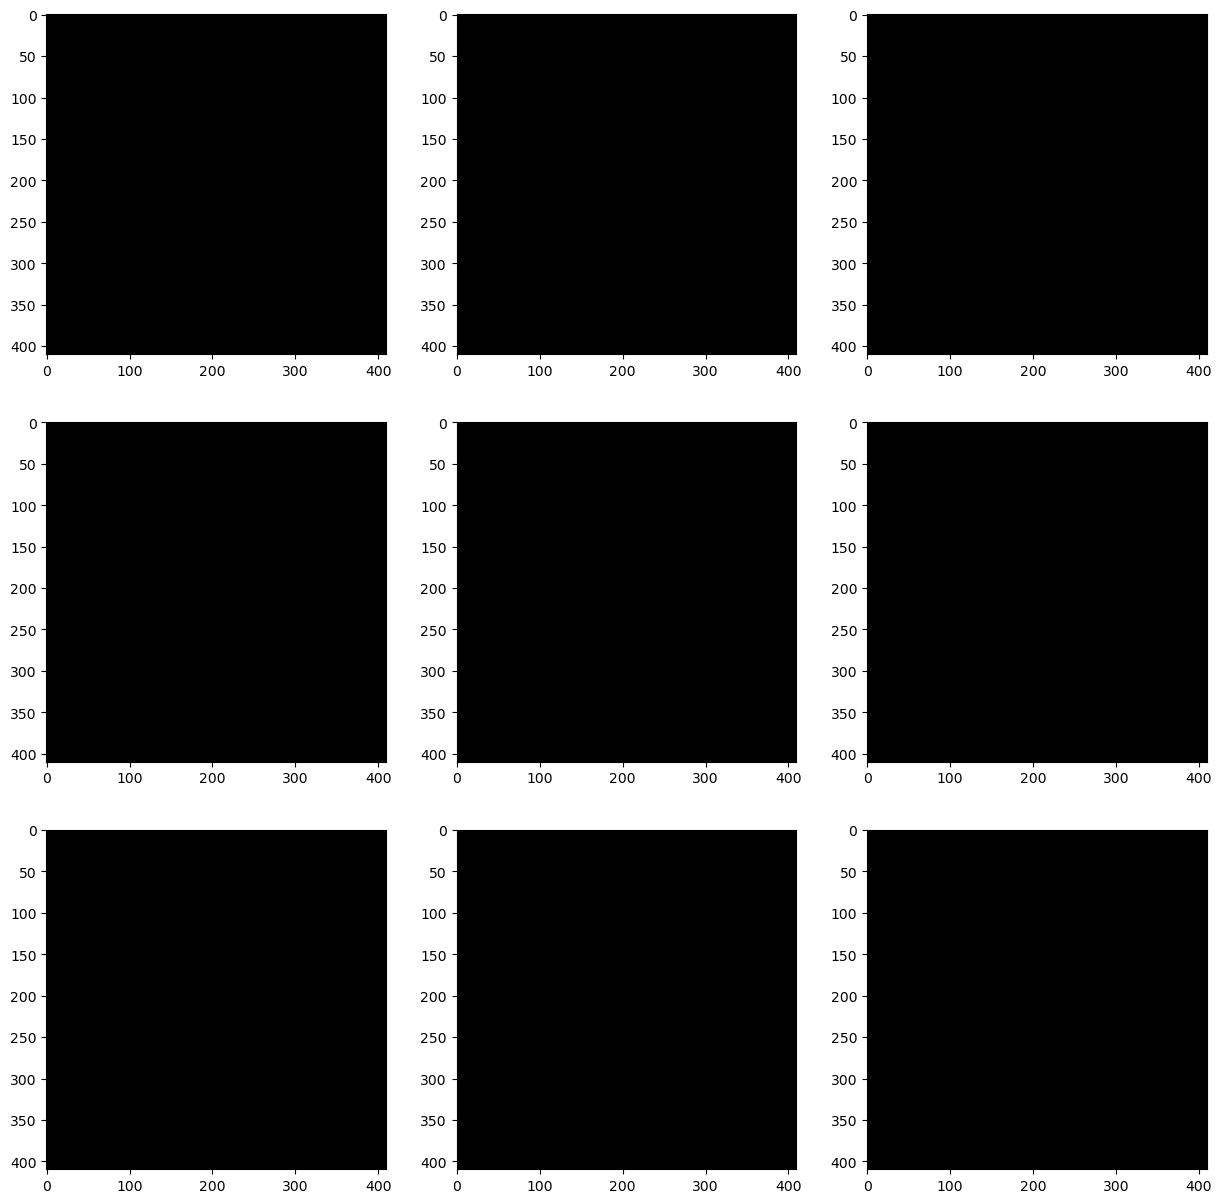

In [6]:
id = 0
spacing = 10

_, axs = plt.subplots(3, 3, figsize=(15, 15))
axs[0, 0].imshow(im_NA[id, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[0, 1].imshow(im_NA[id + spacing, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[0, 2].imshow(im_NA[id + 2 * spacing, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[1, 0].imshow(im_gauss1[id, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[1, 1].imshow(im_gauss1[id + spacing, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[1, 2].imshow(im_gauss1[id + 2 * spacing, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[2, 0].imshow(im_gauss15[id, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[2, 1].imshow(im_gauss15[id + spacing, :, :], cmap="nipy_spectral", interpolation='nearest')
axs[2, 2].imshow(im_gauss15[id + 2 * spacing, :, :], cmap="nipy_spectral", interpolation='nearest')
plt.show()

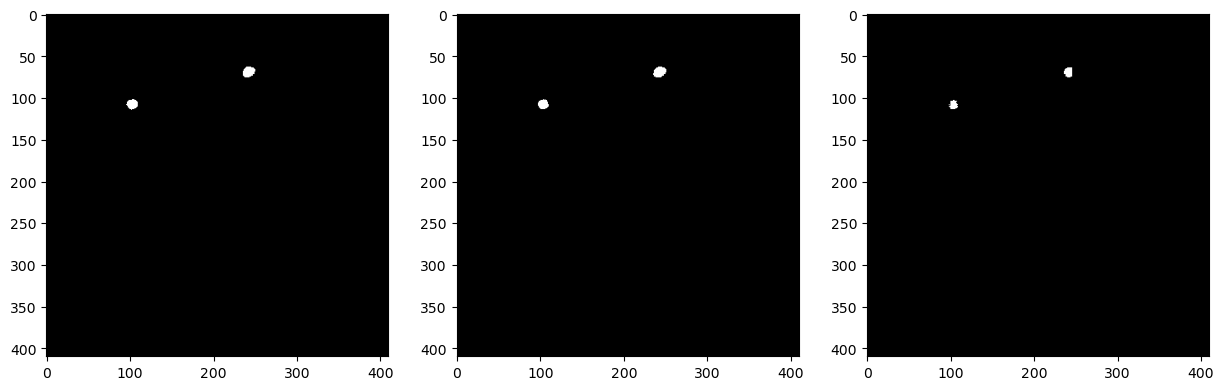

In [22]:
mask_NA = im_NA[20] == 10
mask_gauss1 = im_gauss1[20] == 10
mask_gauss15 = im_gauss15[20] == 10
_, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(mask_NA, cmap="gray")
axs[1].imshow(mask_gauss1, cmap="gray")
axs[2].imshow(mask_gauss15, cmap="gray")
plt.show()

In [36]:
np.unique(im_gauss1[mask])

array([ 0,  1,  2,  8,  9, 10, 14, 15, 25, 26], dtype=uint8)

In [49]:
mask = get_segmentation_mask(im_NA, im_gauss1, id=10)
HD_score = hamming(im_NA[mask], im_gauss1[mask])
print(f"Hamming Score: {1 - HD_score}")

Hamming Score: 0.8361096586240382


In [48]:
mask_10_NA = im_NA == 10
mask_10_gauss1 = im_gauss1 == 10
mask_10_gauss15 = im_gauss15 == 10
iou_score = jaccard_index_numpy(mask_10_NA, mask_10_gauss1)
print(iou_score)

0.8361096586240383


In [66]:
import numpy as np
from numpy.typing import NDArray
from tqdm import tqdm
from typing import Dict, Any

def jaccard_index(prediction: NDArray[Any], target: NDArray[Any]) -> float:
    """
    Computes IoU for a given target and prediction numpy arrays
    """
    intersection = np.sum(prediction & target)
    union = np.sum(prediction | target)
    return intersection / np.maximum(union, 1e-8)

def per_class_iou_consistency(prediction: NDArray[Any], target: NDArray[Any]) -> Dict[Any, float]:
    classes = np.unique(target)
    iou_scores: Dict[int, float] = {}
    for cls in tqdm(classes):
        mask_pred = prediction == cls
        mask_target = target == cls
        iou = jaccard_index(mask_pred, mask_target)
        iou_scores[cls] = iou
    return iou_scores

def per_class_NHD_consistency(prediction: NDArray[Any], target: NDArray[Any]) -> Dict[Any, float]:
    classes = np.unique(target)
    nhd_scores: Dict[int, float] = {}
    for cls in tqdm(classes):
        mask = get_segmentation_mask(target, prediction, id=cls)
        HD_score = hamming(target[mask], prediction[mask])
        nhd_scores[cls] = 1 - HD_score
    return nhd_scores

In [58]:
iou_consistency = per_class_iou_consistency(im_gauss15, im_NA)

100%|██████████| 37/37 [00:03<00:00, 10.53it/s]


In [67]:
NHD_consistency = per_class_NHD_consistency(im_gauss15, im_NA)

100%|██████████| 37/37 [00:12<00:00,  3.06it/s]


In [77]:
from model_ranking import (
    get_border_mask,
    assign_unique_ids_to_value,   
)
from skimage.metrics import (
    adapted_rand_error,  # pyright: ignore[reportUnknownVariableType]
)
from typing import Optional, Tuple

In [ ]:
def ForegroundRestrictedAdaRandError_consistency(
    prediction: NDArray[Any], 
    target: NDArray[Any],
    num_dilations: Optional[int] = None,
    num_erosions: Optional[int] = None,
) -> Tuple[float, float, float]:
    instance_mask = get_mask(target, prediction, threshold=0)

    if num_dilations is not None and num_erosions is not None:
        border_mask = get_border_mask(
            img=target, num_dilations=num_dilations, num_erosions=num_erosions
        )
        instance_mask = np.logical_and(instance_mask, ~border_mask)

    are, prec, rec = adapted_rand_error( # pyright: ignore[reportUnknownVariableType]
        assign_unique_ids_to_value(target[instance_mask], value=[0]),
        assign_unique_ids_to_value(prediction[instance_mask], value=[0]),
    )
    assert isinstance(are, float), f"are is not a float: {are}"
    assert isinstance(prec, float), f"prec is not a float: {prec}"
    assert isinstance(rec, float), f"rec is not a float: {rec}"
    return are, prec, rec

In [65]:
instance_mask = get_mask(im_NA, im_gauss15, threshold=0)
# border_mask = get_border_mask(
#     img=im_NA, num_dilations=1, num_erosions=1
# )
# instance_mask = np.logical_and(instance_mask, ~border_mask)
rand_score = adapted_rand_error(
    assign_unique_ids_to_value(im_NA[instance_mask], value=[0]),
    assign_unique_ids_to_value(im_gauss15[instance_mask], value=[0]),
)
print(rand_score)

(0.03607593795112418, 0.9654446932974327, 0.9624082134317855)


In [79]:
are, prec, rec = ForegroundRestrictedAdaRandError_consistency(
    im_gauss15, im_NA
)
print(f"Foreground Restricted Adapted Rand Error: {are}, Precision: {prec}, Recall: {rec}")

Foreground Restricted Adapted Rand Error: 0.03607593795112418, Precision: 0.9654446932974327, Recall: 0.9624082134317855
